# Exercise 1

In [4]:
!pip install scikit-fuzzy

   ---------------------------------------- 0.0/920.8 kB ? eta -:--:--
    -------------------------------------- 20.5/920.8 kB 640.0 kB/s eta 0:00:02
   ---- ----------------------------------- 102.4/920.8 kB 1.5 MB/s eta 0:00:01
   -------------------- ------------------- 460.8/920.8 kB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 920.8/920.8 kB 6.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\Benjo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Service Membership Functions:


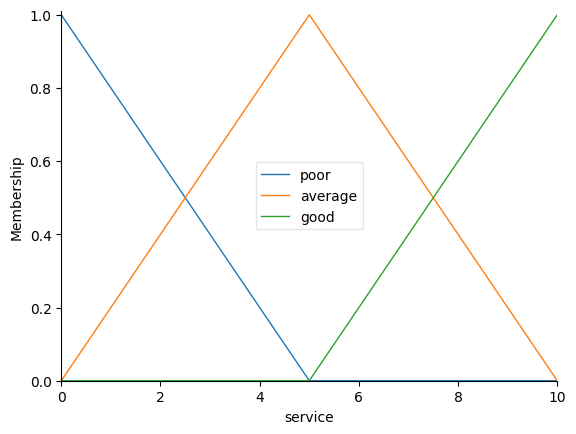


Food Quality Membership Functions:


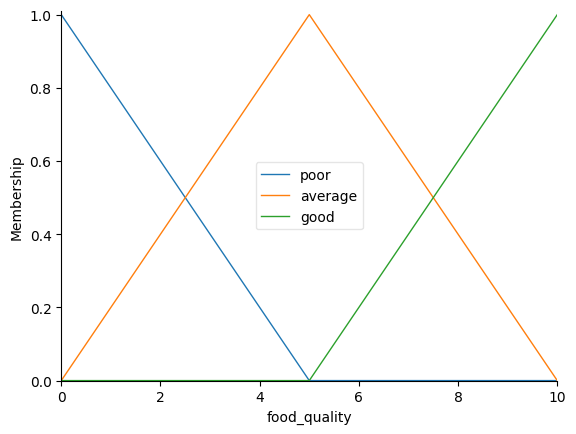


Tip Membership Functions:


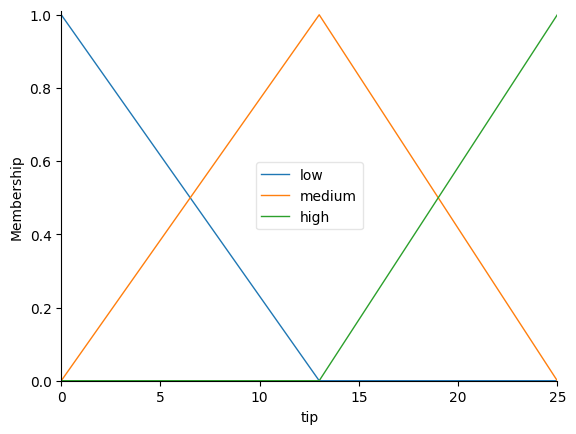

Default names for auto-generated MFs for service and food_quality will be 'poor', 'average', 'good'.


In [6]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl 
import matplotlib.pyplot as plt

# --- Part (a): Define Antecedents (Inputs) and Consequent (Output) ---
quality_range = np.arange(0, 11, 1)
tip_range = np.arange(0, 26, 1)

# Create Fuzzy Control Variables
service = ctrl.Antecedent(quality_range, 'service')
food_quality = ctrl.Antecedent(quality_range, 'food_quality')

# Consequent (Output)
tip = ctrl.Consequent(tip_range, 'tip')

# --- Part (b): Define Membership Functions ---

service.automf(3)
food_quality.automf(3)

tip['low']    = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high']   = fuzz.trimf(tip.universe, [13, 25, 25])

# --- You can view the membership functions (optional) ---
print("Service Membership Functions:")
service.view()
plt.show()

print("\nFood Quality Membership Functions:")
food_quality.view()
plt.show()

print("\nTip Membership Functions:")
tip.view()
plt.show()

print("Default names for auto-generated MFs for service and food_quality will be 'poor', 'average', 'good'.")

In [7]:
# --- Part (c): Define the Fuzzy Rules ---

rule1 = ctrl.Rule(service['good'] | food_quality['good'], tip['high'])

rule2 = ctrl.Rule(service['average'], tip['medium'])

rule3 = ctrl.Rule(service['poor'] & food_quality['poor'], tip['low'])

print("\nRules defined:")
print("Rule 1:", rule1)
print("Rule 2:", rule2)
print("Rule 3:", rule3)


Rules defined:
Rule 1: IF service[good] OR food_quality[good] THEN tip[high]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 2: IF service[average] THEN tip[medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 3: IF service[poor] AND food_quality[poor] THEN tip[low]
	AND aggregation function : fmin
	OR aggregation function  : fmax


In [8]:
# --- Part (d): Create the Control System ---

tipping_ctrl_system = ctrl.ControlSystem([rule1, rule2, rule3])

print("Control System created with the defined rules.")
print(tipping_ctrl_system) 

Control System created with the defined rules.


In [9]:
# --- Part (e): Create a Control System Simulation ---

tipping_simulation = ctrl.ControlSystemSimulation(tipping_ctrl_system)

print("Control System Simulation created.")
print("The system is now ready to accept inputs and compute the tip.")

Control System Simulation created.
The system is now ready to accept inputs and compute the tip.



--- Simulation Results ---
Given Service Quality: 9.8
Given Food Quality: 6.5
Recommended Tip Percentage: 19.85%
This result is around the 20% mark, as expected by the PDF example.

Visualizing the aggregated output and defuzzified result for 'tip':


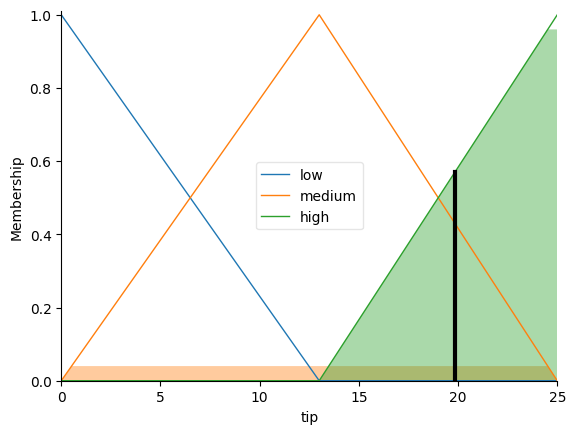

In [10]:
# --- Part (f): Simulate the System with Specific Inputs ---

try:
    tipping_simulation.input['service'] = 9.8
    tipping_simulation.input['food_quality'] = 6.5
except Exception as e:
    print(f"Error setting inputs. Have you defined antecedents named 'service' and 'food_quality'?")
    print(f"Details: {e}")

try:
    tipping_simulation.compute()
except Exception as e:
    print(f"Error during computation. Inputs might not be set correctly or rules/MFs might have issues.")
    print(f"Details: {e}")

try:
    recommended_tip = tipping_simulation.output['tip']
    print(f"\n--- Simulation Results ---")
    print(f"Given Service Quality: 9.8")
    print(f"Given Food Quality: 6.5")
    print(f"Recommended Tip Percentage: {recommended_tip:.2f}%")

    if 18.0 <= recommended_tip <= 22.0:
        print("This result is around the 20% mark, as expected by the PDF example.")
    else:
        print("This result deviates from the PDF's expectation of ~20%. Check rules and MFs if discrepancy is large.")

    print("\nVisualizing the aggregated output and defuzzified result for 'tip':")
    tip.view(sim=tipping_simulation)
    plt.show()

except Exception as e:
    print(f"Error getting output. Has compute() been called successfully? Is 'tip' the correct output variable name?")
    print(f"Details: {e}")


# Exercise 2


--- Simulation Results (Task 2) ---
Given Service Quality: 9.8
Given Food Quality: 6.5
Recommended Tip Percentage (0-50% scale): 41.65%

Visualizing the aggregated output and defuzzified result for 'tip_task2':


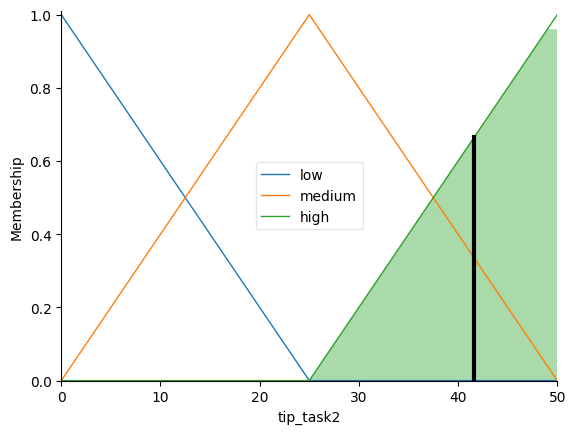

In [11]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

quality_range = np.arange(0, 11, 1)
tip_range_task2 = np.arange(0, 51, 1)

service_task2 = ctrl.Antecedent(quality_range, 'service_task2')
food_quality_task2 = ctrl.Antecedent(quality_range, 'food_quality_task2')
tip_task2 = ctrl.Consequent(tip_range_task2, 'tip_task2')

service_task2['poor']    = fuzz.trimf(service_task2.universe, [0, 0, 5])  
service_task2['average'] = fuzz.trapmf(service_task2.universe, [2, 4, 6, 8]) 
service_task2['good']    = fuzz.trimf(service_task2.universe, [5, 10, 10]) 

food_quality_task2['poor']    = fuzz.trimf(food_quality_task2.universe, [0, 0, 5])
food_quality_task2['average'] = fuzz.trapmf(food_quality_task2.universe, [2, 4, 6, 8]) 
food_quality_task2['good']    = fuzz.trimf(food_quality_task2.universe, [5, 10, 10])

tip_task2['low']    = fuzz.trimf(tip_task2.universe, [0, 0, 25])   
tip_task2['medium'] = fuzz.trimf(tip_task2.universe, [0, 25, 50]) 
tip_task2['high']   = fuzz.trimf(tip_task2.universe, [25, 50, 50])

rule1_task2 = ctrl.Rule(service_task2['good'] | food_quality_task2['good'], tip_task2['high'])
rule2_task2 = ctrl.Rule(service_task2['average'], tip_task2['medium'])
rule3_task2 = ctrl.Rule(service_task2['poor'] & food_quality_task2['poor'], tip_task2['low'])

tipping_ctrl_system_task2 = ctrl.ControlSystem([rule1_task2, rule2_task2, rule3_task2])
tipping_simulation_task2 = ctrl.ControlSystemSimulation(tipping_ctrl_system_task2)

service_input_val = 9.8
food_input_val = 6.5

try:
    tipping_simulation_task2.input['service_task2'] = service_input_val
    tipping_simulation_task2.input['food_quality_task2'] = food_input_val
except Exception as e:
    print(f"Error setting inputs: {e}")

try:
    tipping_simulation_task2.compute()
except Exception as e:
    print(f"Error during computation: {e}")

try:
    recommended_tip_task2 = tipping_simulation_task2.output['tip_task2']
    print(f"\n--- Simulation Results (Task 2) ---")
    print(f"Given Service Quality: {service_input_val}")
    print(f"Given Food Quality: {food_input_val}")
    print(f"Recommended Tip Percentage (0-50% scale): {recommended_tip_task2:.2f}%")

    print("\nVisualizing the aggregated output and defuzzified result for 'tip_task2':")
    tip_task2.view(sim=tipping_simulation_task2)
    plt.show()

except Exception as e:
    print(f"Error getting output: {e}")